In [1]:
# Variational autoencoder in Numpy without AI or reference code
#
# Honest list of all resources used
#   Feed-forward networks: Michael Nielsen, Neural Networks and Deep Learning, Ch. 1 and Ch. 2, without reading reference code examples
#   Gradients and backpropagation: 
#       -> 3Blue1Brown: Backpropagation, intuitively / Backpropagation calculus
#       -> ritvikmath: "Backpropogation: Data Science Concepts"
#       -> https://tutorial.math.lamar.edu/classes/calci/linearapproximations.aspx
#       -> Softmax function: https://en.wikipedia.org/wiki/Softmax_function / https://medium.com/data-science/derivative-of-the-softmax-function-and-the-categorical-cross-entropy-loss-ffceefc081d1
#   SGD:
#       -> https://en.wikipedia.org/wiki/Stochastic_gradient_descent 
#       -> https://www.geeksforgeeks.org/deep-learning/adam-optimizer/
#       -> Jacob Murri (UCLA), Math 118 Lecture Notes 
#       -> Brendan Martin (UCLA), discussion on ADAM 
#
#   Autoencoders:
#       -> Durk Kingma, Max Welling: An Introduction to Variational Autoencoders 
#               (I had to do a lot of reading to understand what they were saying, since I've never taken Bayesian stats)
#       -> https://apxml.com/courses/introduction-autoencoders-feature-learning/chapter-3-how-autoencoders-learn/autoencoder-loss-functions
#       -> https://medium.com/retina-ai-health-inc/variational-inference-derivation-of-the-variational-autoencoder-vae-loss-function-a-true-story-3543a3dc67ee
#       -> https://stats.stackexchange.com/questions/323568/help-understanding-reconstruction-loss-in-variational-autoencoder



In [2]:
import numpy as np
import copy

In [458]:
# =========  1: The forward pass ===========
# 1.1 Creating the linear layers 
# A linear layer's weight matrix has size (output, input)
# 
# Per-neuron outputs per scalar j are ∑_i (w_j)_i * x_i + b_j, where i is the input dimension, and j is the output dimension
# Hence the j'th row of W corresponds to the vector w_j 
# All rows dot the same vector x
# -> Output of len j is the composition W @ x + b

class Layer(): 
    def function(self):
        return NotImplementedError
    def grad(self):
        return NotImplementedError
    index = None
    output = None
    next = None #Pointers for next and prev
    prev = None

class LinearLayer(Layer): 
    weights: np.array #(output_size, input_size)
    bias = np.array #(output_size, )
    def __init__(self, input_size: int, output_size: int): 
        rng = np.random.default_rng()
        self.weights = rng.uniform(-0.001, 0.001, (output_size, input_size)) #Initialize with small uniform weights
        self.bias = rng.uniform(-0.001, 0.001, output_size)    
    def __call__(self, x: np.array): 
        return self.weights @ x + self.bias
    def size(self): 
        return f"In: {self.weights.shape[-1]}, out: {self.weights.shape[0]}"
    def __repr__(self):
        return(f"LinearLayer: {self.size()}")
    def grad(self, *args, **kwargs): 
        return self.weights.T

In [4]:
# 1.2 Non-linear functions
# In a perceptron, we take a singular output w1x1 + w2x2 + ... wnxn, same as dot product w * x, 
# We "accept" if the sum exceeds some certain number, b, otherwise we reject
# Mathematically equivalent to H(w*x + b)
# Because of the piecewise behavior, over multiple layers a small weight change that modifies 0->1 can drastically change behavior
# sigmoid: maps R -> (0,1), smooth version of H(x)
# Because vectorized functions are R^n -> R^n, then the derivative with respect to an input vector will also have to technically be a diagonal matrix
# where all off-diagonal terms are 0

class Nonlinear(Layer):
    name = "nonlinear"
    def __call__(self, z: np.array): 
        return self.function(z)
    def __repr__(self):
        return f"{self.name}"

class Sigmoid(Nonlinear):
    def __init__(self): 
        self.function = lambda z: (1+np.exp(-z))**-1
        self.grad = lambda z: np.diag(self.function(z)*(1-self.function(z)))
        self.name = "sigmoid"
class ReLU(Nonlinear):
    def __init__(self):
        self.function = lambda z: np.maximum(0, z)
        self.grad = lambda z: np.diag(np.where(z > 0, 1,0))
        self.name = "relu"

# 1.21 final activation function thru softmax
# We want to turn the final linear layer output into a probability distribution
class Softmax(Nonlinear):
    def __init__(self): 
        self.name = "softmax"
        self.function = lambda z: np.exp(z - np.max(z)) / np.sum(np.exp(z - np.max(z)))
    # Since softmax is not a vectorized function, then each output depends on all inputs,
    # making the function a jacobian matrix 
    # Although the jacobian matrix contains functions of x_i, the softmax derivative only uses 
    # simple transformations of the original output, since diagonal entries are (y_1)(1-y_1) and 
    # off-diagonal entries are -y_i*y_j, where y_i = exp(x_i).
    # The (i,j)'th entry is y_i {i=j} - y_i*y_j
    # => diag(y) - yy^T
    def grad(self, z):
        y = self.function(z)
        return (np.diag(y) - np.outer(y, y))
        

In [ ]:
# 1.3 Creating a neural network
# Add linear or nonlinear modules with `add`, can be any function that works on numpy arrays
class NeuralNetwork: 
    first_module = None
    last_module = None
    input_dim, output_dim = None, None
    parameters = []
    def get_modules(self):
        current = self.first_module
        modules = [current]
        while current.next:
            current = current.next
            modules.append(current)
        return modules
    
    def add(self, module): 
        if self.first_module is None: 
            self.first_module = module
            self.last_module = module
            if isinstance(module, LinearLayer):
                self.input_dim = module.weights.shape[0]
        else:
            module.prev = self.last_module
            self.last_module.next = module
            self.last_module = module
        # Add parameters and update output dimensionality if it's a linear layer
        if isinstance(module, LinearLayer): 
            self.parameters.append({"weights": module.weights, "biases": module.bias})
            self.output_dim = module.weights.shape[-1]
    def __init__(self): 
        self.modules = []
        self.parameters = []
    def forward(self, input):
        current_module = self.first_module
        current_module.input = input
        output = input
        while current_module:
            output = current_module(output)
            current_module.output = output
            current_module = current_module.next
        return output
    def forward_batched(self, input): #TODO work on this
        current_module = self.first_module
        input = np.atleast_2d(input)  # treat as (batch, dim), single examples become batch=1
        current_module.input = input
        output = input
        while current_module:
            batch_out = np.stack([current_module(x) for x in output])
            current_module.output = batch_out
            output = batch_out
            current_module = current_module.next
        return output
    def __repr__(self):
        for i, module in enumerate(self.get_modules()):
            print(f"module {i}: {module}")
    def __add__(self, NN2): 
        # This method chains together the output of the neural network to NN
        # Returns a new NeuralNetwork, keeping the originals with their current modules
        # Updates to the new NN will affect the current modules
        NN = NeuralNetwork()
        for module in self.get_modules():
            NN.add(copy.copy(module))
        for module in NN2.get_modules():
            NN.add(copy.copy(module))
        NN.input_dim = self.input_dim
        NN.output_dim = NN2.output_dim or self.output_dim

        return NN

NN = NeuralNetwork()
NN.add(module=LinearLayer(input_size=10, output_size=8))
NN.add(module=Sigmoid())
NN.add(module=LinearLayer(input_size=8, output_size=6))
NN.add(module=Sigmoid())
NN.add(module=LinearLayer(input_size=6, output_size=2))
NN.add(module=Softmax())

In [6]:
# =========  2: Using gradients to update the weights in neural networks ===========
# 2.0 Loss is a function of the weights
# We initialize our neural network with random weights and biases for the linear layers. 
# If we put in an input, the output is probably wrong in most cases.   
#
#This makes it that if we can quantify how "wrong" the random-weight answer is, 
# then it is possible to find some other setting for all the weights and biases 
# inside the neural network that make the answer *less wrong* 
#
# In this case, a neural network is a function f(weights + biases) from the 
# parameter dimension to the output dimension, therefore the loss is a
# function Loss(weights + biases) -> R
# 
# Furthermore, the neural network itself should be a differentiable function by
# the chain rule from calc, so as long as our loss function is differentiable 
# we can find the partial derivative of Loss(w + b) with respect to every individual w, b
#
# By the first order linear approximation, f(a+∆x) ≈ f(a) + f'(a)∆x 
# Therefore if we move in direction of -f'(a) we reduce f (basic principle of GD)

# 2.1 MSE 
# Since our goal is a autoencoder, which does a recreation, MSE is a more natural metric than Cross-entropy loss 
#
# When a neural network with randomized weights spits out an output distribution,
# we have to score the output distribution based on something. 
# MSE is a reliable metric, the squared term punishes large errors while allowing small ones to exist. 
# This makes our loss error prioritize correcting the biggest differences from training reference while
# caring less about being perfectly precise on nearly-good weight differences
# It's nice and differentiable with the derivative being a linear function

class LossFunction(): 
    def __call__(self, *args, **kwargs):
        return self.function(*args, **kwargs)
    def function(self, *args, **kwargs): 
        raise NotImplementedError
    def grad(self, *args, **kwargs):
        raise NotImplementedError

class MeanSquaredError(LossFunction):
    def function(self, x, ref): 
        return np.sum((x-ref)**2)/(2*len(x))
    def grad(self, x, ref): 
        return (x-ref)/len(x)

# 2.2 Recursive chain rule applications make it easy to find individual derivatives
#
# I had to write this in a markdown below for the math
# For a given output neuron, its activation depends on the weights connecting to it and 
# its bias, but also the activations that all the neurons prior to it connected 
# The later a given operation is, we can relate it to dC more easily,
# If we can anchor somewhere and find a recursive formula between layers given our repeated 
# LinearLayer + sigmoid structure, we can easily recreate the chain rule with less computation
# For instance, if we can find a relation between dCdz2, and dz2dz1, we can find dC with respect 
# To any linear layer output z. 
# 
# since z is a composition of w and b, then one more chain rule application can easily find dCdw or dCdb

$$C = \frac{1}{2n}\sum_k (\hat{y}_k - y_k)^2$$
$$\text{where the neural network output } \hat y = \text{softmax}(z^{(L)}) $$
$$ \frac{\partial C}{\partial z^{(L)}_j} = \sum_i \frac{\partial \hat y_i }{\partial z^{(L)}_j} \frac{\partial C}{\partial \hat y _i}$$
$$\sigma \text{ is a nice vectorized function, but all values } y_i \text{ depend on } z^{(L)}_j \text{ in softmax}$$
$$\frac{\partial \hat y_i}{\partial z_j} = \begin{cases} \hat y_i - \hat y_i \hat y_j, \quad i = j \\ - \hat y_i \hat y_j, \quad i \neq j \end{cases} \implies \frac{\partial \hat y}{\partial z} = \text{diag}( \hat y) - \hat y \hat y^\top \text{ (A jacobian)}$$
$$\boxed{ \frac{\partial C}{\partial z^{(L)}} = \frac{1}{n} \left((\text{diag}(\hat y) - \hat y \hat y^\top) (\hat y - y) \right)}$$

$$\frac{\partial C}{\partial z^{(L-1)}} = \frac{\partial x^{(L-1)}}{\partial z^{(L-1)}} \frac{\partial z^{(L)}}{\partial x^{(L-1)}} \frac{\partial C}{\partial z^{(L)}}$$
$$\text{break to calc derivatives...}$$

$$ x^{(L)}_i = \sigma(z^{(L)}_i) \rightarrow \frac{\partial x_i}{\partial z^{(L)}_j} = \begin{cases} \sigma(z^{(L)}_i)(1-\sigma(z^{(L)}_i)), \quad i = j \\ 0, \quad \quad i \neq j\end{cases}
$$
$$z^{(L)} = W^{(L)}x^{(L-1)} + b^{(L)} \implies \frac{\partial{z^{(L)}}}{\partial x^{(L-1)}} = (W^{(L)})^\top$$
$$ \boxed{\implies \frac{\partial C}{\partial z^{(L-1)}} = \text{diag}\left(x^{(L-1)} \odot (1-x^{(L-1)}) \right) (W^{(L)})^\top \frac{\partial C}{\partial z^{(L)}}}$$



$$\text{Recursion on weights:}$$
$$\frac{\partial C}{\partial w_{ij}} = \sum_k \frac{\partial z^{(L)}_k}{\partial w^{{(L)}}_{i,j}} \frac{\partial C}{\partial z^{(L)}_k}$$
$$z^{(L)}_k = \sum_j w_{k,j}x_j + b^{(L)}_k \implies \frac{\partial z^{(L)}_k}{\partial w^{(L)}_{i, j}} = \begin{cases} x_j^{(L)}, \quad i = k \\ 0,\quad \text{ otherwise}\end{cases}$$
$$\text{therefore } \frac{\partial C}{\partial w^{(L)}_{ij}} = \frac{\partial z_i^{(L)}}{\partial w_{i, j}^{(L)}} \frac{\partial C}{\partial z^{{(L)}}_i} = x_j \frac{\partial C}{\partial z^{(L)}_i}, \quad \left[\frac{\partial C}{\partial W^{(L)}} \right]_{ij} = \frac{\partial C}{\partial z^{(L)}_i} x^{(L-1)}_j$$
$$ \boxed{\implies \frac{\partial C}{\partial W^{(L)}} = \frac{\partial C}{\partial z^{(L)}} \otimes x^{(L-1)}}$$
$$\text{Recursion on biases:}$$
$$z^{(L)}_k = \sum_j w_{k,j}^{(L)}x_j^{(L-1)} + b^{(L)}_k \implies \frac{\partial z^{(L)}_k}{\partial b^{(L)}_{i}} = \begin{cases}1, \quad i = k \\ 0, \quad i \neq k \end{cases} $$
$$\implies \frac{\partial C}{\partial b^{(L)}_i} = \frac{\partial C}{\partial z^{(L)}_i}$$
$$\boxed{\frac{\partial C}{\partial b^{(L)}} = \frac{\partial C}{\partial z^{(L)}}}$$



In [7]:
# Starting at the last layer, compute the first gradients dC/dz^L using only the last layer
# Then apply recursively

# Uses original loss from initialization to recursively compute error with respect to layers
# Final nonlinear output z^L  ...
# No idea how pytorch implements this, so this may be very inefficient
# Loss functions propagate gradients straight backwards (since they are numpy-vectorized)
# Linear layers distribute gradients from earlier layers to affect later layers 
# 
# Although we could find dCdz according to the recursion since our normal neural networks
# are set up using just Linear -> Sigmoid -> Linear ... in order, I think that traveling backwards
# thru layers and multiplying gradients is both easier to implement and also maybe more robust 
# to layers that don't follow the structure
#
# in either case, we find dCdz at a Sigmoid layer, and then use the outer product formula to find dCdW

class Loss:
    def __init__(self, model, **loss_args): 
        self.model = model
        self.loss_args = loss_args
        self.output_loss = self.loss_fn(**self.loss_args)
    def update(self, **loss_args):
        self.loss_args = loss_args
        self.output_loss = self.loss_fn(**self.loss_args) 
        return self.output_loss

    def backward(self): 
        last = self.model.last_module #Nonlinear module, something like Sigmoid or Softmax
        # print(f"Softmax/sigmoid jacobian norm: {np.linalg.norm(last.grad(last.prev.output))}")
        # print(f"Softmax/sigmoid jacobian input norm: {np.linalg.norm(last.prev.output)}")
        dCdz = last.grad(last.prev.output) @ self.loss_fn.grad(**self.loss_args) #dydz * dLdy
        last.gr = dCdz
        self.dCdzs = [dCdz]
        self.xs = []
        # Walk backwards, using the chain rule to calculate derivatives
        # When you encounter a Nonlinearl layer o(z_) = x_, save dCdz_
        # Save the corresponding x^(L-1) for each dCdz^(L), shifted one unit back
        # This is all done using regular matmul
        current = last.prev
        while current.prev is not None: 
            dmdm_ = current.grad(current.prev.output)
            dCdm = current.next.gr
            current.gr =  dmdm_@dCdm
            # print(f"{current} dCdlayer norm: {np.linalg.norm(current.gr)}")
            if isinstance(current, Nonlinear):
                self.dCdzs.append(current.gr)
                self.xs.append(current.output)
            current = current.prev 
        self.xs.append(current.input)

        # Find dCdW with the outer product
        self.dCdWs = [
            np.outer(dCdz, x) for dCdz, x in zip(self.dCdzs, self.xs)
        ]
        return [
            {"weights": dCdW, "biases": dCdb} 
            for dCdW, dCdb in zip(reversed(self.dCdWs), reversed(self.dCdzs))
        ]


class MSE_loss(Loss):
    def __init__(self, model, **loss_args):
        self.loss_fn = MeanSquaredError()
        super().__init__(model, **loss_args)


class L2(LossFunction):
    def function(self, x, ref): 
        return np.sum((x-ref)**2)/2
    def grad(self, x, ref): 
        return (x-ref)
class L2_loss(Loss):
    def __init__(self, model, **loss_args):
        self.loss_fn = L2()
        super().__init__(model, **loss_args)


In [8]:
# =========  3: Defining optimizers that work on gradient outputs ===========
# Our optimizer class is called on an individual NeuralNetwork object, meaning we'll have to 
# split the VAE into its two neural networks for weight modification, which is OK. 
# At each step, indicate to the optimizer what modifications you want to make and where, 
# with a list[{"weights": np.array, "biases": np.array}]) structure that's the same as the
# structure of model.parameters

# Any optimizer can reuse the step method, the only difference between SGD/Adam is that prior to 
# stepping, they would update dW with whatever formula they do it with

class Optimizer:
    def __init__(self, model, lr): 
        self.lr = lr
        self.model=model
        self.stp = 0
        self.linear_layers = {}

        i = 0
        for module in model.get_modules():
            if isinstance(module, LinearLayer):
                self.linear_layers[i] = module
                i += 1
        # The state will track each individual linear layer by index
        # over training so that we can take into consideration the 
        # previous step's per-layer gradients 
        self.state = {}  

    def step(self, grad): 
        self.stp += 1
        for LL_idx, L in self.linear_layers.items(): 
            g = grad[LL_idx] #{"weights": dCdW , "biases": dCdb}
            if LL_idx not in self.state:
                self.state[LL_idx] = self._init_state(g)
            dW, db = self._update(LL_idx, g) 
            L.weights -= dW
            L.bias -= db

    def _init_state(self, g): 
        raise NotImplementedError
    def _update(self, idx, g): 
        raise NotImplementedError

# 3.1 SGD, with momentum, uses a simple moving average of the two last gradients 
# (or just the current training example's gradient with no momentum), and it 
# steps with a fixed step size multiplier

class SGD(Optimizer): 
    def __init__(self, model, lr, momentum: float=0): 
        super().__init__(model, lr)
        self.momentum = momentum

    def _init_state(self, g): 
        return {"m_W": np.zeros_like(g["weights"]), "m_b": np.zeros_like(g["biases"])}
    def _update(self, LL_idx, g): 
        s = self.state[LL_idx]
        # With a nice recursive formula here, this automatically updates s["m_W/b"]
        s["m_W"] = self.momentum * s["m_W"] + (1 - self.momentum) * g["weights"]
        s["m_b"] = self.momentum * s["m_b"] + (1 - self.momentum) * g["biases"]
        return self.lr * s["m_W"], self.lr * s["m_b"]

# 3.2 ADAM optimizer
# With SGD, we are only approximating the first-order gradient, often badly
# So what use would approximating the parameters^2 terms for the second derivative? 
# Our sample gradients are from a distribution, and so if we can find the variance
# 
# Apparently, the terms dCd0^2 are supposed to approximate the diagonal entries of H, 
# but I can't see how this is possible
class Adam(Optimizer): 
    def __init__(self, model, lr, b1=0.9, b2=0.999):
        super().__init__(model, lr)
        self.b1 = b1
        self.b2 = b2
        
    def _init_state(self, g):
        return {
            "m_W": np.zeros_like(g["weights"]), "v_W": np.zeros_like(g["weights"]),
            "m_b": np.zeros_like(g["biases"]), "v_b": np.zeros_like(g["biases"]),
        }
    def _update(self, LL_idx, g): 
        s = self.state[LL_idx]
        s["m_W"] = self.b1 * s["m_W"] + (1 - self.b1) * g["weights"]
        s["m_b"] = self.b1 * s["m_b"] + (1 - self.b1) * g["biases"]
        s["v_W"] = self.b2 * s["v_W"] + (1 - self.b2) * (g["weights"] ** 2)
        s["v_b"] = self.b2 * s["v_b"] + (1 - self.b2) * (g["biases"] ** 2)

        hat_m_W = s["m_W"] / (1 - self.b1 ** self.stp)
        hat_m_b = s["m_b"] / (1 - self.b1 ** self.stp)
        hat_v_W = s["v_W"] / (1 - self.b2 ** self.stp)
        hat_v_b = s["v_b"] / (1 - self.b2 ** self.stp)

        dW = self.lr * hat_m_W / (np.sqrt(hat_v_W) + 1e-6)
        db = self.lr * hat_m_b / (np.sqrt(hat_v_b) + 1e-6)
        return dW, db

In [10]:
input = np.array([1,1,1,1,1,1,1,1,1,1,])
output = NN.forward(input)
correct = np.array([0.6, 0.4])
print(f"Output: {output}")

l = MSE_loss(NN,x=output, ref=correct)
print(f"Output loss: {l.output_loss}")

grad = l.backward()

Output: [0.498462 0.501538]
Output loss: 0.005154982418010056


In [11]:
NN_copy = copy.deepcopy(NN)
ad = Adam(NN, 0.01, 0.5, 0.5)
ad.step(grad)
sg = SGD(NN_copy, 0.1, 0.5)
sg.step(grad)

output2 = NN.forward(input)
output3 = NN_copy.forward(input)
print(f"SGD output: {output3}, loss: {l.update(x=output3, ref=correct)}")
print(f"Adam output: {output2}, loss: {l.update(x=output2, ref=correct)}")


SGD output: [0.50004571 0.49995429], loss: 0.004995430239225274
Adam output: [0.51839244 0.48160756], loss: 0.003329897170962345


In [112]:
# =========  4: Variational Autoencoder ===========
#
# Autoencoders themselves are pretty simple: minimize reconstruction error, and the model finds an approximate
# parameter distribution in its lower dimension for each category. To me, I like to think of autoencoders as a nonlinear version of PCA
# where the latent space is our low-rank projection V^Tx, with r kept components corresponding to the dimension r of the smallest network layer
# While it can find distributions here pretty well, an arbitrary combination in latent space is not guaranteed 
# to look like anything after reconstruction, so it's not good at generalization/generation
# 
# The trick with VAEs is to minimize latent loss in addition to reconstruction loss, meaning that it forces the lower-dimensional
# distribution to resemble whatever prior we think the latent space has 
# The paper says how any sufficiently commplicated function can map any arbitrary distribution to another arbitrary distribution, meaning that 
# the VAE has to learn that sufficiently complicated function that can turn a nice distribution (e.g the gaussian) into our output distribution
#
# At a very high level, we just penalize the approximated latent distribution q(z|x) with something like KL, 
# even though the Kingma I read discusses this in much more detail I can't really understand (ELBO and true posteriors and monte-carlo estimators, etc)
# Although the original paper uses the negative log likelihood, maximizing this is equivalent to minimizing L2 error
# The Encoder portion outputs a distribution, which is penalized to resemble our prior N(0,1)
# This distribution is sampled and fed to the decoder for recreation, and this is also penalized to create a good reconstruction
#
# Sampling from a distribution means that we also need to model the variance, which can be done with... 
# A secondary neural network alongside the encoder step for variance
# Standard implementations are said to use logvar for numerical stability, which can easily be converted back with exp

class Encoder():
    def __init__(self):
        self.mean_head = NeuralNetwork()
        self.logvar_head = NeuralNetwork()
    def add(self, module):
        self.mean_head.add(module)
        self.logvar_head.add(copy.deepcopy(module))

    def forward(self, input):
        mu = self.mean_head.forward(input)
        logvar = self.logvar_head.forward(input)
        return mu, logvar
    
encoder = Encoder()
encoder.add(LinearLayer(16, 8))
encoder.add(Sigmoid())
encoder.add(LinearLayer(8,4))
encoder.add(Sigmoid())


In [12]:
# Math break 2: 
# The VAE loss function we're using is C(y, ref, mu, logvar) = MSE(y, ref) + KL(mu, logvar)
# The KL term does not depend on any of the layers in the decoder, hence dKLdW for decoder
# weights is zero
# Encoder w&b can affect the KL term in the loss,
# All w&b can affect the reconstruction term

$$C(\hat y, \hat \mu, \hat \ell) = \text{MSE}(\hat y(\hat \mu, \hat \ell)) + \beta \cdot KL(\hat \mu, \hat\ell)$$
$$KL(\hat \mu, \hat \ell) = -\frac{1}{2} \sum_d (1+ \hat \ell_d - \hat \mu^2_d - \exp(\hat \ell_d)), \quad \hat \ell = \log(\hat \sigma^2)$$

$$ \frac{\partial KL}{\partial z^{\hat \mu, (L)}} = \frac{\partial \hat \mu}{\partial z^{\hat \mu, (L)}} \frac{\partial KL}{\partial \hat \mu}=   \frac{\partial \hat \mu}{\partial z^{\hat \mu, (L)}}  \odot \mu \quad \text{since } \hat\mu = \sigma(z^{\hat \mu, (L)})$$


$$\text{therefore } \boxed{\frac{\partial KL}{\partial W^{\mu, (L)}} = \frac{\partial KL}{\partial z^{\mu, (L)}} \otimes x^{\mu, (L-1)}}$$

$$\frac{\partial KL}{\partial z^{\hat \ell, (L)}} = \frac{\partial \hat \ell}{\partial z^{\hat \ell, (L)}} \frac{\partial KL}{\partial \hat \ell} = 
\hat \ell(1-\hat \ell) \ \odot \ \frac{1}{2}(\exp\hat \ell - 1)
$$


In [13]:
# The derivative of the MSE with respect to the mu and logvar would have been straightforward if not for the 
# reparameterization term r. Happilly, it is differentiable now. 
# In the case of the weights for mu, the contribution term of the MSE is exactly the same as it is in 
# the normal case, since drdu = I, nice
# In the logvar case, we have a different scaling matrix, which is a little bit more complicated, but 
# also simply a scalar
#
# Based on the derivatives, it seems that the smaller logvar and the sampled z are, the gradients get 
# less magnitude. This makes sense, since (i have no idea why this makes sense. Small gradients mean the 
# logvar head is not trained, meaning it's good where it currently is)
# This term actually wants to force logvar to 0, but making logvar 0 would increase the KL penalty 

$$\frac{\partial MSE(\hat y)}{\partial z^{\hat \mu, (L)}} = 
\frac{\partial \mu}{\partial z^{\mu, (L)}} \frac{\partial r}{\partial \mu }
\frac{\partial z^{(0)}}{\partial r}\frac{\partial MSE(\hat y)}{\partial z^{(0)}}

$$
$$r(\hat\mu, \hat\ell) = \hat \mu + \epsilon *\exp(\frac 1 2 \hat \ell); \  \epsilon \sim N(0,1), \quad z^{(0)} = W^{(0)} r + b^{(0)}, \quad $$
$$\boxed{\frac{\partial MSE}{\partial \hat z^{\hat\mu, (L)}} = \frac{\partial MSE}{\partial z^{(L)}}}$$
$$\text{Decoder head: }$$
$$\frac{\partial r}{\partial \ell} = \frac 1 2  z \exp(\frac 12  \hat \ell)$$

$$\boxed{\frac{\partial MSE}{\partial z^{\hat \ell, (L)}} = \frac{\partial \mu}{\partial z^{\mu, (L)}} \odot  \frac 1 2  z \exp(\frac 12  \hat \ell)\odot
(W^{(0)})^\top\frac{\partial MSE(\hat y)}{\partial z^{(0)}}}

In [14]:
# Because our total loss combines MSE/Reconstruction error and scaled KL/latent error, 
# then the total contribution is as follows: 
# MSE/Reconstruction error term: 
#   - decoder: no change from default backpropagation
#   - encoder: no change in the mean-generating network, multiply weights by 1/2log(1/2l) for the logvar
# KL term
#   - decoder: KL has no contribution
#   - encoder: multiply all KL contributions by the scaling factor b
#
# Pseudoalgorithm reusing existing code: 
#   - Create two seperate NeuralNetwork objects linking the encoder's mean head and variance head,
#     backprop on this combined neural network will yield the correct contribution of gradients for 
#     all mean-generating encoder and decoder modules
#   - Save the deepest dCdz from the decoder, perform the additional matrix multiplication by drdl, 
#     and then do backpropagation as normal
#   - Find the beta-scaled contribution of the KL divergence term for the encoder modules by 
#     just defining a new KL_normal loss function and perform backwards() with slightly different
#     matmuls on the right side

In [113]:
class VariationalAutoencoder():
    def reparameterize(self, mu, logvar): 
        rng = np.random.default_rng()
        self.eps = rng.standard_normal(size=mu.size)
        return mu + self.eps*np.exp(0.5*logvar)
    
    def __init__(self, encoder, decoder):
        self.encoder = encoder
        self.decoder = decoder
        self.input_dim = encoder.mean_head.input_dim
        self.output_dim = decoder.output_dim
        self.latent_dim = decoder.input_dim

    def forward(self, input): 
        self.input = input
        mu, logvar = self.encoder.forward(input)
        sample = self.reparameterize(mu, logvar)
        output = self.decoder.forward(sample)
        return output, mu, logvar

decoder = NeuralNetwork()
decoder.add(LinearLayer(4,8))
decoder.add(Sigmoid())
decoder.add(LinearLayer(8,16))
decoder.add(Sigmoid())


In [114]:
# 4.1: KL-divergence has an easy normal form for comparisons with the prior N(0,1)
# I got this formula from a website, so I'm not including the math
# When calling Loss.backward, the class automatically calculates self.loss_fn.grad(**self.loss_args)
# which I don't want to modify since it's a base class attribute. 
# The lazy way is to add a method indicating to KL_normal which variable's gradient to return

class KL_normal(LossFunction):
    def function(self, mu, logvar):
        return -0.5*np.sum((1+logvar - mu**2 - np.exp(logvar))) 
    def grad(self, mu, logvar):
        if self.grad_mode == "mean": return mu
        if self.grad_mode == "logvar": return 0.5*(np.exp(logvar)-1)
class KL_normal_Loss(Loss):
    def __init__(self, model, **loss_args):
        self.loss_fn = KL_normal()
        self.loss_fn.grad_mode = "mean"
        super().__init__(model, **loss_args)
    def set_grad_mode(self, mode="mean"):
        if mode == "mean": self.loss_fn.grad_mode = "mean"
        elif mode == "logvar": self.loss_fn.grad_mode = "logvar"
        else: raise ValueError


In [444]:
# 4.2: Loss functions for VAE
# 
# While the VAELoss operates on a VariationalAutoencoder which I couldn't generalize to be a NeuralNetwork, 
# we can still re-use the underlying model functionalities from the general Loss class, 
# But the class is more of a combined wrapper for both the MSE_loss and KL_normal_Loss classes working together

class VAELoss(Loss):
    def loss_fn(self, **loss_args):
        outputs = loss_args.get("outputs")
        targets = loss_args.get("targets")
        mu = loss_args.get("mu")
        l = loss_args.get("l")
        recon_error = self.l2(outputs, targets)
        latent_error = self.kl(mu, l)
        return recon_error + self.beta*latent_error
    def __init__(self, VAE, beta: int=1, **loss_args):   
        self.beta = beta
        self.l2 = L2()
        self.kl = KL_normal()
        super().__init__(VAE, **loss_args)

    def backward(self):
        # Like backwards in normal loss, but with two return modules
        # Updates for the complete reconstruction module according to normal recursive formula
        # Updates for the logvar part of the encoder have KL contribution multiplied by beta
        
        # ====== Terms dependent on MSE:
        mean_reconstructor = self.model.encoder.mean_head + self.model.decoder 
        outputs = self.loss_args.get("outputs")
        targets = self.loss_args.get("targets")
        self.mr_loss = L2_loss(model=mean_reconstructor, x=outputs, ref=targets)
        # Encoder and decoder mean layers have regular backprop since drdu = I
        self.dRC = self.mr_loss.backward() 

        # Count # of linear layers in the encoder in order to split the combined mean->reconstruction backprop
        d_index = len(self.model.encoder.mean_head.parameters)
        dRCdzs = [self.mr_loss.dCdzs[d_index+1]] # Get earliest dRCdz (last in the array, since we backpropagated)
        logvar_module = self.model.encoder.logvar_head.last_module
        # Calculate bridge between logvar encoder/decoder layers through r(u, l) using the scaling factor drdl
        drdl = 0.5 * self.model.eps * np.exp(0.5*logvar_module.output)
        W_0 = self.model.decoder.first_module.weights #first decoder module
        dldz = logvar_module.grad(logvar_module.prev.output)
        dRCdz_l = dldz @ drdl * ( W_0.T @ dRCdzs[-1])
        logvar_module.gr = dRCdz_l
        self.dRCdzs_l = [dRCdz_l]
        xs_l = []

        logvar_module = logvar_module.prev
        while logvar_module.prev is not None: #Backprop like normal after extra matmul
            dmdm_ = logvar_module.grad(logvar_module.prev.output)
            dRCdm = logvar_module.next.gr
            logvar_module.gr = dmdm_ @ dRCdm
            if isinstance(logvar_module, Nonlinear):
                self.dRCdzs_l.append(logvar_module.gr)
                xs_l.append(logvar_module.output)
            logvar_module = logvar_module.prev
        xs_l.append(logvar_module.input)

        self.dRCdWs_l = [np.outer(dRCdz, x) for dRCdz, x in zip(self.dRCdzs_l, xs_l)]
        self.dRC_l = [
            {"weights": dRCdW_l, "biases": dRCdb}
            for dRCdW_l, dRCdb in zip(reversed(self.dRCdWs_l), reversed(self.dRCdzs_l))
        ]
        # ====== Terms dependent on KL - mean and logvar generators have different dKL
        mu = self.loss_args.get("mu")
        l = self.loss_args.get("l")
        self.KL_loss = KL_normal_Loss(model=self.model.encoder.mean_head, mu=mu, logvar=l)
        self.dKL_u = self.KL_loss.backward()

        self.KL_loss.set_grad_mode("logvar")
        self.dKL_l = self.KL_loss.backward()

        # Final loss using beta to scale
        dC_l = [{
            "weights": self.dRC_l[LL_index]["weights"] + self.beta * self.dKL_l[LL_index]["weights"],
            "biases": self.dRC_l[LL_index]["biases"] + self.beta * self.dKL_l[LL_index]["biases"],
        } for LL_index in range(len(self.dRC_l))]

        dC_u = [{
            "weights": self.dRC[i]["weights"] + self.beta * self.dKL_u[i]["weights"]
                    if i < len(self.dKL_u) else self.dRC[i]["weights"],
            "biases": self.dRC[i]["biases"] + self.beta * self.dKL_u[i]["biases"]
                    if i < len(self.dKL_u) else self.dRC[i]["biases"],
        } for i in range(len(self.dRC))]

        encoder_length = len(self.dKL_u)
        return {
            "decoder": dC_u[encoder_length:], 
            "mean_encoder": dC_u[:encoder_length],
            "logvar_encoder": dC_l
        }


In [18]:
# =========  5: Testing on MNIST ===========
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)


In [48]:
# Regular autoencoder
autoencoder = NeuralNetwork()
autoencoder.add(LinearLayer(784, 128))
autoencoder.add(Sigmoid())
autoencoder.add(LinearLayer(128, 16))
autoencoder.add(Sigmoid()) #Latent dim
autoencoder.add(LinearLayer(16, 128))
autoencoder.add(Sigmoid())
autoencoder.add(LinearLayer(128, 784))
autoencoder.add(Sigmoid())

sample_ind = np.random.choice(x_train.shape[0], 30000, replace=False)
numbers = x_train[sample_ind]


Training...: 100%|██████████| 30000/30000 [02:24<00:00, 207.70it/s, mean_rc=26.5527]


In [422]:
autoencoder_opt = Adam(autoencoder, lr=0.001)

import tqdm
reconstruction_loss = []
reconstruction_loss = []
pbar = tqdm.tqdm(numbers[0:1], desc="Training...")

per_number_loss = []
for i, number in enumerate(pbar):
    y = autoencoder.forward(number)
    loss = MSE_loss(autoencoder, x=y, ref=number)
    grad = loss.backward()
    autoencoder_opt.step(grad)
    per_number_loss.append(loss.output_loss)
    
    if i % 128 == 0:
        recent =  np.mean(per_number_loss)
        per_number_loss = []
        pbar.set_postfix(mean_rc=f"{recent:.4f}",)
        reconstruction_loss.append(recent)

Training...: 100%|██████████| 1/1 [00:00<00:00, 45.72it/s, mean_rc=0.0035]


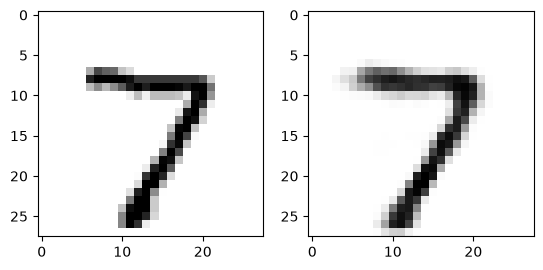

In [408]:
test = x_test[0]
def view_reconstruction(model, example):
    rc = model.forward(example)
    if isinstance(rc, tuple): 
        rc = rc[0]
    plt.subplot(1, 2, 1)
    plt.imshow(example.reshape(28, 28), cmap="gray_r")
    plt.subplot(1, 2, 2)
    plt.imshow(rc.reshape(28, 28), cmap="gray_r")
    plt.imshow(rc.reshape(28,28), cmap="gray_r");
view_reconstruction(autoencoder, test)

In [488]:
MNIST_ENCODER = Encoder()
MNIST_ENCODER.add(LinearLayer(784, 128))
MNIST_ENCODER.add(Sigmoid())
MNIST_ENCODER.add(LinearLayer(128, 16))
MNIST_ENCODER.add(Sigmoid())

MNIST_DECODER = NeuralNetwork()
MNIST_DECODER.add(LinearLayer(16, 128))
MNIST_DECODER.add(Sigmoid())
MNIST_DECODER.add(LinearLayer(128, 784))
MNIST_DECODER.add(Sigmoid())

MNIST_VAE = VariationalAutoencoder(MNIST_ENCODER, MNIST_DECODER)


___

In [ ]:
reconstruction_loss = []

In [489]:
sample_ind = np.random.choice(x_train.shape[0], 5000, replace=True)
numbers = x_train[sample_ind]
ADAM_LR = 0.0000001
BETA = 0

decoder_opt = Adam(MNIST_VAE.decoder, lr=ADAM_LR, b1=0.8, b2=0.95)
encoder_opt_u = Adam(MNIST_VAE.encoder.mean_head, lr=ADAM_LR)
encoder_opt_l = Adam(MNIST_VAE.encoder.logvar_head, lr=ADAM_LR)

import tqdm
step_loss = []

pbar = tqdm.tqdm(numbers, desc="Training...")
for i, number in enumerate(pbar):
    y, mu, logvar = MNIST_VAE.forward(number)
    loss = VAELoss(MNIST_VAE, beta=BETA,
                   outputs=y, targets=number, 
                   mu=mu, l=logvar,)
    grads = loss.backward()
    decoder_opt.step(grads["decoder"])
    encoder_opt_u.step(grads["mean_encoder"])
    encoder_opt_l.step(grads["logvar_encoder"])

    exit
    step_loss.append({"rc": loss.mr_loss.output_loss, "KL": loss.KL_loss.output_loss})

    if i % 512 == 0 and i != 0 :
        mean_rc = sum(x["rc"] for x in step_loss) / len(step_loss)
        mean_KL = sum(x["KL"] for x in step_loss) / len(step_loss)
        step_loss =[]
        
        pbar.set_postfix(mean_rc=f"{mean_rc:.4f}",mean_KL=f"{mean_KL:.4f}",)
        reconstruction_loss.append({"rc": mean_rc, "KL": mean_KL})
    del grads

Training...: 100%|██████████| 5000/5000 [01:15<00:00, 66.08it/s, mean_KL=3.2600, mean_rc=88.7809] 


In [490]:
# gradients get smaller as they move back, even though we only use a few sigmoids
dCdWs_reconstruction = loss.mr_loss.dCdWs
dCdWs_KL = loss.KL_loss.dCdWs
print(f"Reconstructor weight norms: {[float(np.linalg.norm(dC)) for dC in dCdWs_reconstruction]}")
print(f"KL weight norms: {[float(np.linalg.norm(dC)) for dC in dCdWs_KL]}")

Reconstructor weight norms: [18.882137677514255, 0.180813667369809, 0.0027524110424191704, 3.7977491581564963e-05]
KL weight norms: [1.8375543894447317, 0.025223111913660234]


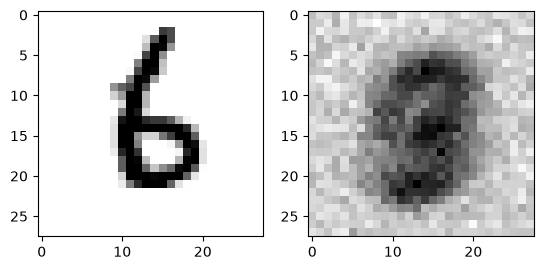

In [494]:
view_reconstruction(MNIST_VAE, example2)

In [466]:
y1, mu1, l1 = MNIST_VAE.forward(example)
y2, mu2, l2 = MNIST_VAE.forward(example2)

In [467]:
mu1, mu2

(array([0.4992403 , 0.50102014, 0.49925641, 0.50126189, 0.49850037,
        0.50110519, 0.5003865 , 0.49926387, 0.4998453 , 0.50006097,
        0.50112919, 0.4989899 , 0.49862562, 0.49898192, 0.49991237,
        0.49905435]),
 array([0.49923728, 0.50102157, 0.49925584, 0.50126233, 0.49850282,
        0.50110137, 0.50038193, 0.49926698, 0.4998417 , 0.5000613 ,
        0.50113228, 0.49898948, 0.49862595, 0.49898439, 0.49991062,
        0.49905459]))